In [1]:
!pip install shap

In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [51]:
df = pd.read_csv("Metabolic Syndrome.csv")
df.head()




,seqn,Age,Sex,Marital,Income,Race,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome
0,62161,22,Male,Single,8200.0,White,81.0,23.3,0,3.88,4.9,92,41,84,0
1,62164,44,Female,Married,4500.0,White,80.1,23.2,0,8.55,4.5,82,28,56,0
2,62169,21,Male,Single,800.0,Asian,69.6,20.1,0,5.07,5.4,107,43,78,0
3,62172,43,Female,Single,2000.0,Black,120.4,33.3,0,5.22,5.0,104,73,141,0
4,62177,51,Male,Married,NaN,Asian,81.1,20.1,0,8.13,5.0,95,43,126,0


In [53]:
before = len(df)

# Droppa rader där nyckelmåtten för kardiometabol risk saknas
df_clean = df.dropna(subset=["WaistCirc", "BMI", "BloodGlucose", "HDL", "Triglycerides"]).copy()

# Fysiologiskt orimliga värden -> NaN (t.ex. inmatningsfel)
for col, lo, hi in [("BMI", 12, 70), ("BloodGlucose", 30, 500), ("WaistCirc", 40, 200)]:
    df_clean.loc[~df_clean[col].between(lo, hi), col] = np.nan

df_clean = df_clean.dropna(subset=["BMI", "BloodGlucose", "WaistCirc"])
print(f"{before} -> {len(df_clean)} rader efter städning")

2401 -> 2311 rader efter städning


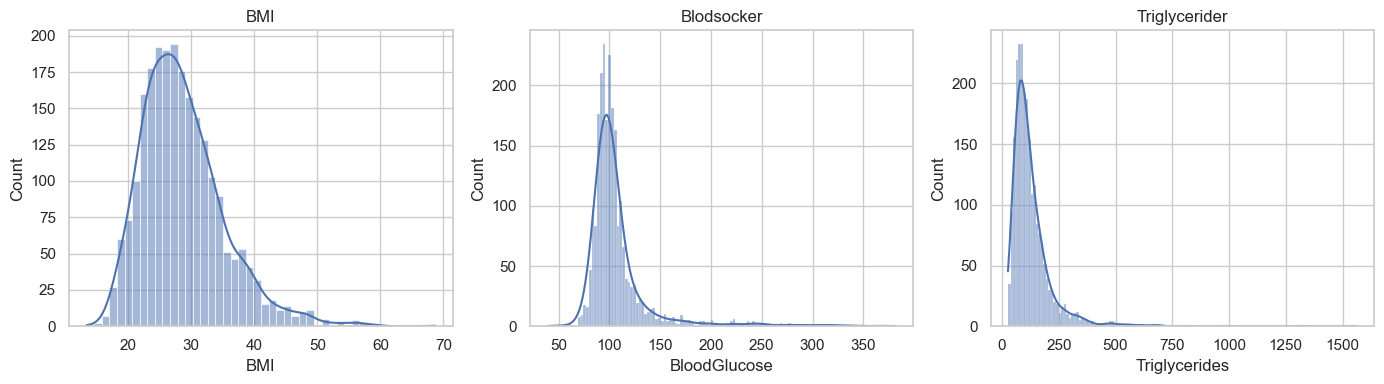

In [55]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(df_clean["BMI"], kde=True, ax=axes[0]); axes[0].set_title("BMI")
sns.histplot(df_clean["BloodGlucose"], kde=True, ax=axes[1]); axes[1].set_title("Blodsocker")
sns.histplot(df_clean["Triglycerides"], kde=True, ax=axes[2]); axes[2].set_title("Triglycerider")
plt.tight_layout()
plt.show()

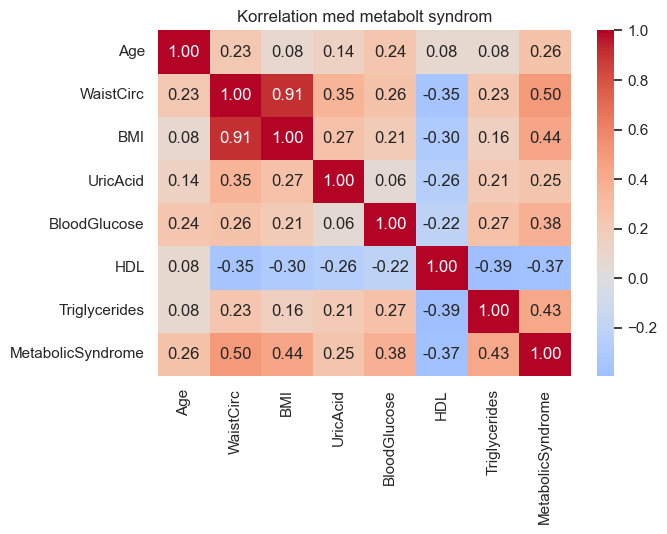

In [57]:
numeric_cols = ["Age", "WaistCirc", "BMI", "UricAcid", "BloodGlucose",
                "HDL", "Triglycerides", "MetabolicSyndrome"]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Korrelation med metabolt syndrom")
plt.tight_layout()
plt.show()

In [59]:
correlations = df_clean[numeric_cols].corr()["MetabolicSyndrome"].sort_values(ascending=False)
print(correlations)

MetabolicSyndrome    1.000000
WaistCirc            0.496494
BMI                  0.440773
Triglycerides        0.427240
BloodGlucose         0.376716
Age                  0.261406
UricAcid             0.248516
HDL                 -0.374187
Name: MetabolicSyndrome, dtype: float64


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

feature_cols_num = ["Age", "WaistCirc", "BMI", "UricAcid", "BloodGlucose", "HDL", "Triglycerides"]
feature_cols_cat = ["Sex", "Race"]
target_col = "MetabolicSyndrome"

X = df_clean[feature_cols_num + feature_cols_cat]
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), feature_cols_num),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]), feature_cols_cat),
])

print(f"Träningsdata: {X_train.shape[0]} rader, testdata: {X_test.shape[0]} rader")
print(f"Andel med metabolt syndrom: {y.mean():.1%}")

Träningsdata: 1848 rader, testdata: 463 rader
Andel med metabolt syndrom: 34.7%


In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

log_reg = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
log_reg.fit(X_train, y_train)

feature_names = (
    feature_cols_num
    + list(log_reg.named_steps["prep"].named_transformers_["cat"]
           .named_steps["onehot"].get_feature_names_out(feature_cols_cat))
)
coefs = pd.Series(log_reg.named_steps["clf"].coef_[0], index=feature_names)
print(coefs.sort_values(ascending=False))

Triglycerides       1.437165
WaistCirc           0.966678
BloodGlucose        0.869275
Age                 0.641558
Race_Hispanic       0.280056
BMI                 0.239765
UricAcid            0.096262
Race_Black          0.000740
Race_Other          0.000419
Race_MexAmerican   -0.015379
Race_White         -0.204730
HDL                -0.603590
Sex_Male           -0.999260
dtype: float64


              precision    recall  f1-score   support

  Inget MetS       0.92      0.93      0.93       302
        MetS       0.87      0.86      0.86       161

    accuracy                           0.90       463
   macro avg       0.90      0.89      0.89       463
weighted avg       0.90      0.90      0.90       463



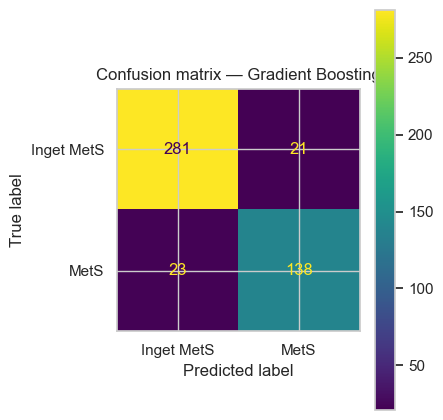

In [173]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Gradient Boosting
gboost = Pipeline([
    ("prep", preprocess),
    ("clf", GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)),
])

# Träna mod
gboost.fit(X_train, y_train)

best_model = gboost
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Inget MetS", "MetS"]))

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Inget MetS", "MetS"], ax=ax)
ax.set_title("Confusion matrix — Gradient Boosting")
plt.tight_layout()
plt.show()

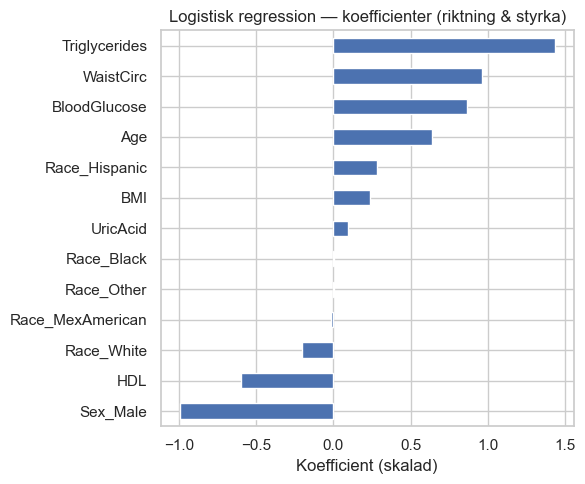

In [83]:
feature_names = (
    feature_cols_num
    + list(log_reg.named_steps["prep"].named_transformers_["cat"]
           .named_steps["onehot"].get_feature_names_out(feature_cols_cat))
)
coefs = pd.Series(log_reg.named_steps["clf"].coef_[0], index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(6, 5))
coefs.plot(kind="barh", ax=ax)
ax.set_title("Logistisk regression — koefficienter (riktning & styrka)")
ax.set_xlabel("Koefficient (skalad)")
plt.tight_layout()
plt.show()

In [85]:
print(coefs.sort_values(ascending=False))

Triglycerides       1.437165
WaistCirc           0.966678
BloodGlucose        0.869275
Age                 0.641558
Race_Hispanic       0.280056
BMI                 0.239765
UricAcid            0.096262
Race_Black          0.000740
Race_Other          0.000419
Race_MexAmerican   -0.015379
Race_White         -0.204730
HDL                -0.603590
Sex_Male           -0.999260
dtype: float64


In [87]:
import shap
import matplotlib.pyplot as plt

In [89]:
%who

ColumnTransformer	 ConfusionMatrixDisplay	 GradientBoostingClassifier	 LogisticRegression	 MinMaxScaler	 OneHotEncoder	 Pipeline	 SimpleImputer	 StandardScaler	 
X	 X_test	 X_train	 ax	 axes	 before	 best_model	 boxcox	 classification_report	 
coefs	 col	 correlations	 dataframe_columns	 dataframe_hash	 df	 df_clean	 dtypes_str	 feature_cols_cat	 
feature_cols_num	 feature_names	 fig	 gboost	 get_dataframes	 getpass	 hashlib	 hi	 import_pandas_safely	 
is_data_frame	 json	 lo	 log_reg	 np	 numeric_cols	 pd	 plt	 preprocess	 
roc_auc_score	 shap	 sns	 target_col	 train_test_split	 y	 y_pred	 y_test	 y_train	 



In [91]:
type(log_reg)

sklearn.pipeline.Pipeline

In [93]:
print(log_reg)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Age', 'WaistCirc', 'BMI',
                                                   'UricAcid', 'BloodGlucose',
                                                   'HDL', 'Triglycerides']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                     

Logistic Regression AUC: 0.930
Gradient Boosting AUC: 0.973


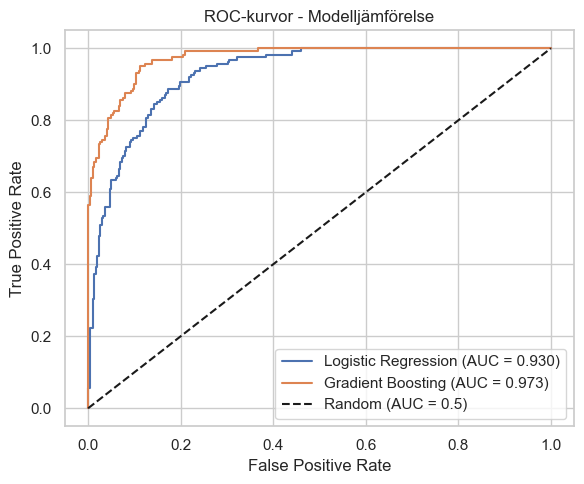

In [95]:
from sklearn.metrics import roc_auc_score, roc_curve

# Förutsäg sannolikheter för båda modellerna
y_prob_log = log_reg.predict_proba(X_test)[:, 1]
y_prob_gb = gboost.predict_proba(X_test)[:, 1]

# Beräkna AUC
auc_log = roc_auc_score(y_test, y_prob_log)
auc_gb = roc_auc_score(y_test, y_prob_gb)

print(f"Logistic Regression AUC: {auc_log:.3f}")
print(f"Gradient Boosting AUC: {auc_gb:.3f}")

# Plotta ROC-kurvor
fig, ax = plt.subplots(figsize=(6, 5))

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
ax.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
ax.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.3f})')

# Diagonal linje (random classifier)
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-kurvor - Modelljämförelse')
ax.legend()
plt.tight_layout()
plt.show()

In [175]:
from sklearn.model_selection import GridSearchCV

# Definiera p att testa
param_grid = {
    'clf__n_estimators': [50, 100, 200],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__max_depth': [3, 4, 5],
    'clf__min_samples_split': [2, 5]
}

# GridSearchobjekt
grid_search = GridSearchCV(
    Pipeline([
        ("prep", preprocess),
        ("clf", GradientBoostingClassifier(random_state=42))
    ]),
    param_grid=param_grid,
    cv=5,  # 5-faldig korsvalidering
    scoring='roc_auc',
    n_jobs=-1,  # Använd alla CPU-kärnor
    verbose=1
)

# sökningen 
grid_search.fit(X_train, y_train)

# resultat
print(f"Bästa AUC (cross-val): {grid_search.best_score_:.3f}")
print(f"Bästa parametrar: {grid_search.best_params_}")

# bäst modell data
best_gboost = grid_search.best_estimator_
y_pred_best = best_gboost.predict(X_test)
y_prob_best = best_gboost.predict_proba(X_test)[:, 1]
auc_best = roc_auc_score(y_test, y_prob_best)

print(f"Test-AUC med bästa modell: {auc_best:.3f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Bästa AUC (cross-val): 0.961
Bästa parametrar: {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Test-AUC med bästa modell: 0.973


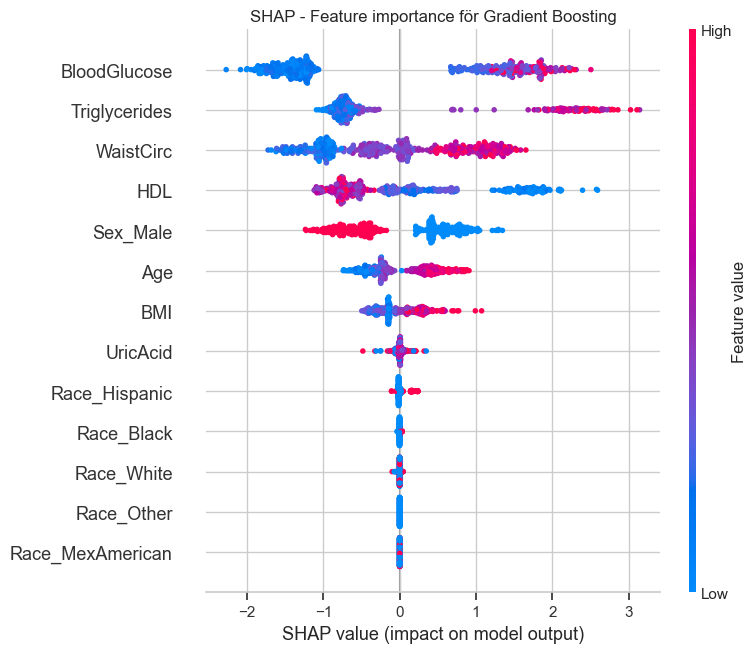

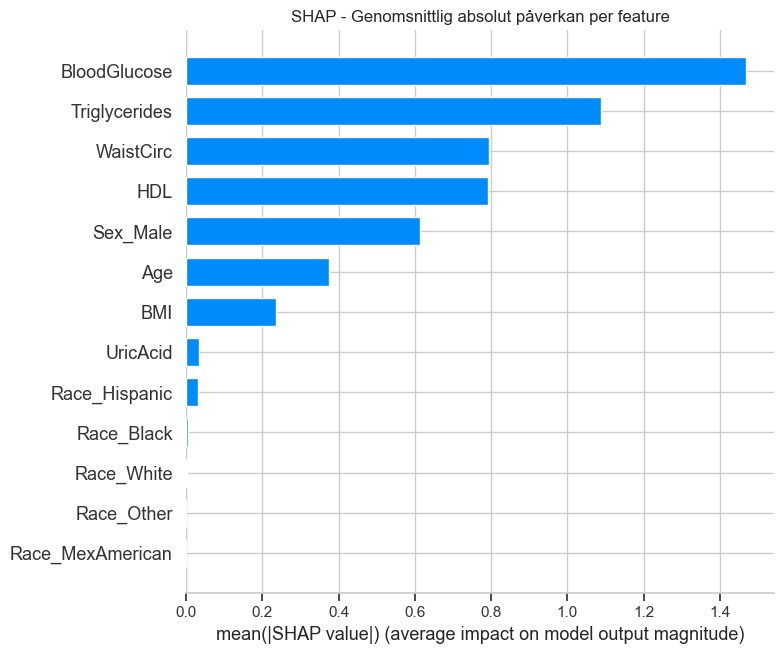


Förklaring för första personen i testdata:


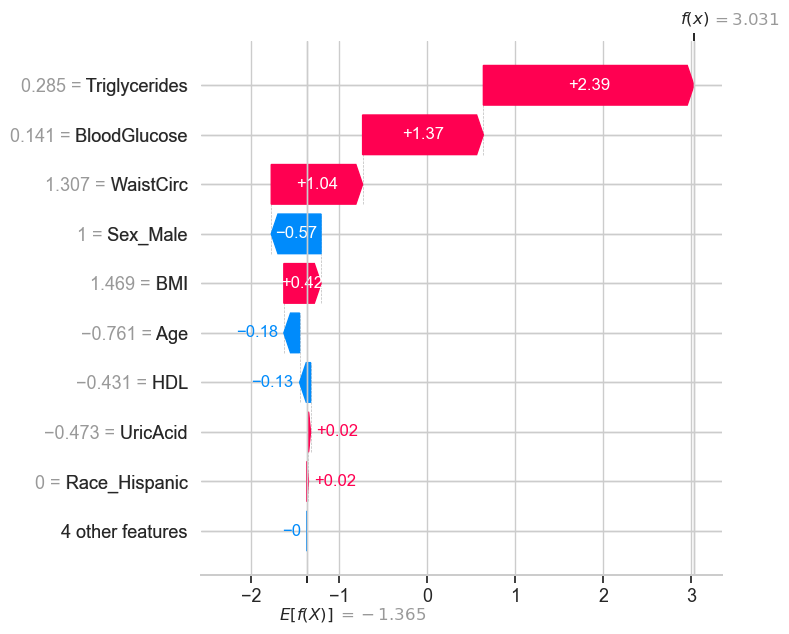

In [176]:
import shap

# Skapa en SHAP-förklarare för din tränade modell
explainer = shap.TreeExplainer(gboost.named_steps['clf'])

# Preprocessa data för SHAP (behöver numerisk data)
X_train_processed = gboost.named_steps['prep'].transform(X_train)
X_test_processed = gboost.named_steps['prep'].transform(X_test)

# SHAP-värden för testdata (kan ta lite tid)
shap_values = explainer.shap_values(X_test_processed)

# Hämta feature efter preprocessing
feature_names_processed = (
    feature_cols_num
    + list(gboost.named_steps['prep']
           .named_transformers_['cat']
           .named_steps['onehot']
           .get_feature_names_out(feature_cols_cat))
)

# Summary plot med viktigaste feature
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names_processed, show=False)
plt.title("SHAP - Feature importance för Gradient Boosting")
plt.tight_layout()
plt.show()

# Bar plot, genomsnittlig påverkan
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names_processed, 
                  plot_type="bar", show=False)
plt.title("SHAP - Genomsnittlig absolut påverkan per feature")
plt.tight_layout()
plt.show()

# Förklara en enskild individ (t.ex. första i test)
print("\nFörklaring för första personen i testdata:")
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0, :],
        base_values=explainer.expected_value,
        data=X_test_processed[0, :],
        feature_names=feature_names_processed
    ),
    show=False
)
plt.tight_layout()
plt.show()

In [169]:
# Jämför prediction från båda modellerna
disagreement = (y_pred != y_pred_best)
print(f"Modellerna är oense i {disagreement.sum()} av {len(y_test)} fall ({disagreement.sum()/len(y_test):.1%})")

# Titta på de fall där modellerna är oense
disagree_indices = np.where(disagreement)[0]
print("\nExempel på fall där modellerna är oense:")
for idx in disagree_indices[:5]:
    print(f"  Person {idx}: LogReg={y_pred[idx]}, GB={y_pred_best[idx]}, Sann={y_test.iloc[idx]}")

# Feature importance Gradient Boosting 
feature_importance = pd.Series(
    gboost.named_steps['clf'].feature_importances_,
    index=feature_names_processed
).sort_values(ascending=False)

print("\nGradient Boosting - Inbyggd feature importance:")
print(feature_importance)

Modellerna är oense i 8 av 463 fall (1.7%)

Exempel på fall där modellerna är oense:
  Person 20: LogReg=1, GB=0, Sann=0
  Person 36: LogReg=0, GB=1, Sann=0
  Person 125: LogReg=0, GB=1, Sann=1
  Person 143: LogReg=1, GB=0, Sann=1
  Person 252: LogReg=0, GB=1, Sann=1

Gradient Boosting - Inbyggd feature importance:
BloodGlucose        0.354033
Triglycerides       0.238759
WaistCirc           0.123353
HDL                 0.099171
BMI                 0.097388
Sex_Male            0.050031
Age                 0.027050
UricAcid            0.007333
Race_Hispanic       0.001225
Race_Black          0.000985
Race_White          0.000673
Race_MexAmerican    0.000000
Race_Other          0.000000
dtype: float64


In [103]:
# 1. Kolla in de 8 personerna där modellerna är oense - vad kännetecknar dem?
disagree_indices = np.where(disagreement)[0]

# Plocka ut deras data
disagree_data = X_test.iloc[disagree_indices].copy()
disagree_data['Sann'] = y_test.iloc[disagree_indices].values
disagree_data['LogReg'] = y_pred[disagree_indices]
disagree_data['GB'] = y_pred_best[disagree_indices]

print("Personer där modellerna är oense:")
display(disagree_data)

# 2. Beskrivande statistik för dessa personer (ligger de på gränsen?)
print("\nMedelvärden för de 8 oense personerna:")
print(disagree_data[feature_cols_num].mean())

print("\nJämfört med hela testdatasetet:")
print(X_test[feature_cols_num].mean())

# 3. Kolla sannolikheter för de oense fallen - är de nära 50%?
y_prob_log_disagree = y_prob_log[disagree_indices]
y_prob_gb_disagree = y_prob_gb[disagree_indices]

print("\nSannolikheter för de oense fallen:")
for i, idx in enumerate(disagree_indices):
    print(f"Person {idx}: LogReg={y_prob_log_disagree[i]:.3f}, GB={y_prob_gb_disagree[i]:.3f}, Sann={y_test.iloc[idx]}")

Personer där modellerna är oense:


,Age,WaistCirc,BMI,UricAcid,BloodGlucose,HDL,Triglycerides,Sex,Race,Sann,LogReg,GB
1268,70,110.7,25.9,3.6,126.0,41,90,Male,White,0,1,0
518,37,127.0,40.1,7.2,106.0,44,104,Male,MexAmerican,0,0,1
917,36,137.5,46.0,8.9,100.0,54,148,Male,Black,1,0,1
1086,63,124.5,35.0,5.1,180.0,46,85,Male,Black,1,1,0
2059,40,105.8,30.3,5.5,103.0,55,75,Male,Hispanic,1,0,1
1992,67,91.1,24.3,2.5,103.0,69,91,Female,Hispanic,1,0,1
1440,68,102.4,29.5,3.9,111.0,71,115,Female,MexAmerican,1,1,0
1888,20,104.7,34.8,4.7,88.0,40,85,Female,Black,0,0,1



Medelvärden för de 8 oense personerna:
Age               50.1250
WaistCirc        112.9625
BMI               33.2375
UricAcid           5.1750
BloodGlucose     114.6250
HDL               52.5000
Triglycerides     99.1250
dtype: float64

Jämfört med hela testdatasetet:
Age               47.943844
WaistCirc         97.955292
BMI               28.636933
UricAcid           5.485313
BloodGlucose     109.734341
HDL               52.747300
Triglycerides    125.317495
dtype: float64

Sannolikheter för de oense fallen:
Person 20: LogReg=0.658, GB=0.626, Sann=0
Person 36: LogReg=0.717, GB=0.484, Sann=0
Person 125: LogReg=0.877, GB=0.478, Sann=1
Person 143: LogReg=0.953, GB=0.516, Sann=1
Person 252: LogReg=0.206, GB=0.373, Sann=1
Person 428: LogReg=0.272, GB=0.346, Sann=1
Person 432: LogReg=0.550, GB=0.598, Sann=1
Person 460: LogReg=0.278, GB=0.455, Sann=0


De 8 oense personerna - fullständig data:


,Age,WaistCirc,BMI,UricAcid,BloodGlucose,HDL,Triglycerides,Sex,Race,Sann,LogReg_prob,GB_prob,LogReg_pred,GB_pred
1268,70,110.7,25.9,3.6,126.0,41,90,Male,White,0,0.657668,0.625539,1,0
518,37,127.0,40.1,7.2,106.0,44,104,Male,MexAmerican,0,0.717357,0.484160,0,1
917,36,137.5,46.0,8.9,100.0,54,148,Male,Black,1,0.877138,0.478341,0,1
1086,63,124.5,35.0,5.1,180.0,46,85,Male,Black,1,0.952712,0.516182,1,0
2059,40,105.8,30.3,5.5,103.0,55,75,Male,Hispanic,1,0.205790,0.372906,0,1
1992,67,91.1,24.3,2.5,103.0,69,91,Female,Hispanic,1,0.271909,0.346378,0,1
1440,68,102.4,29.5,3.9,111.0,71,115,Female,MexAmerican,1,0.550267,0.598223,1,0
1888,20,104.7,34.8,4.7,88.0,40,85,Female,Black,0,0.278218,0.454541,0,1



MetS-kriterier för de oense personerna (uppfyller minst 3 av 4):
Person 20: 2 av 4 kriterier uppfyllda, Sann=0
Person 36: 2 av 4 kriterier uppfyllda, Sann=0
Person 125: 1 av 4 kriterier uppfyllda, Sann=1
Person 143: 2 av 4 kriterier uppfyllda, Sann=1
Person 252: 2 av 4 kriterier uppfyllda, Sann=1
Person 428: 2 av 4 kriterier uppfyllda, Sann=1
Person 432: 2 av 4 kriterier uppfyllda, Sann=1
Person 460: 2 av 4 kriterier uppfyllda, Sann=0


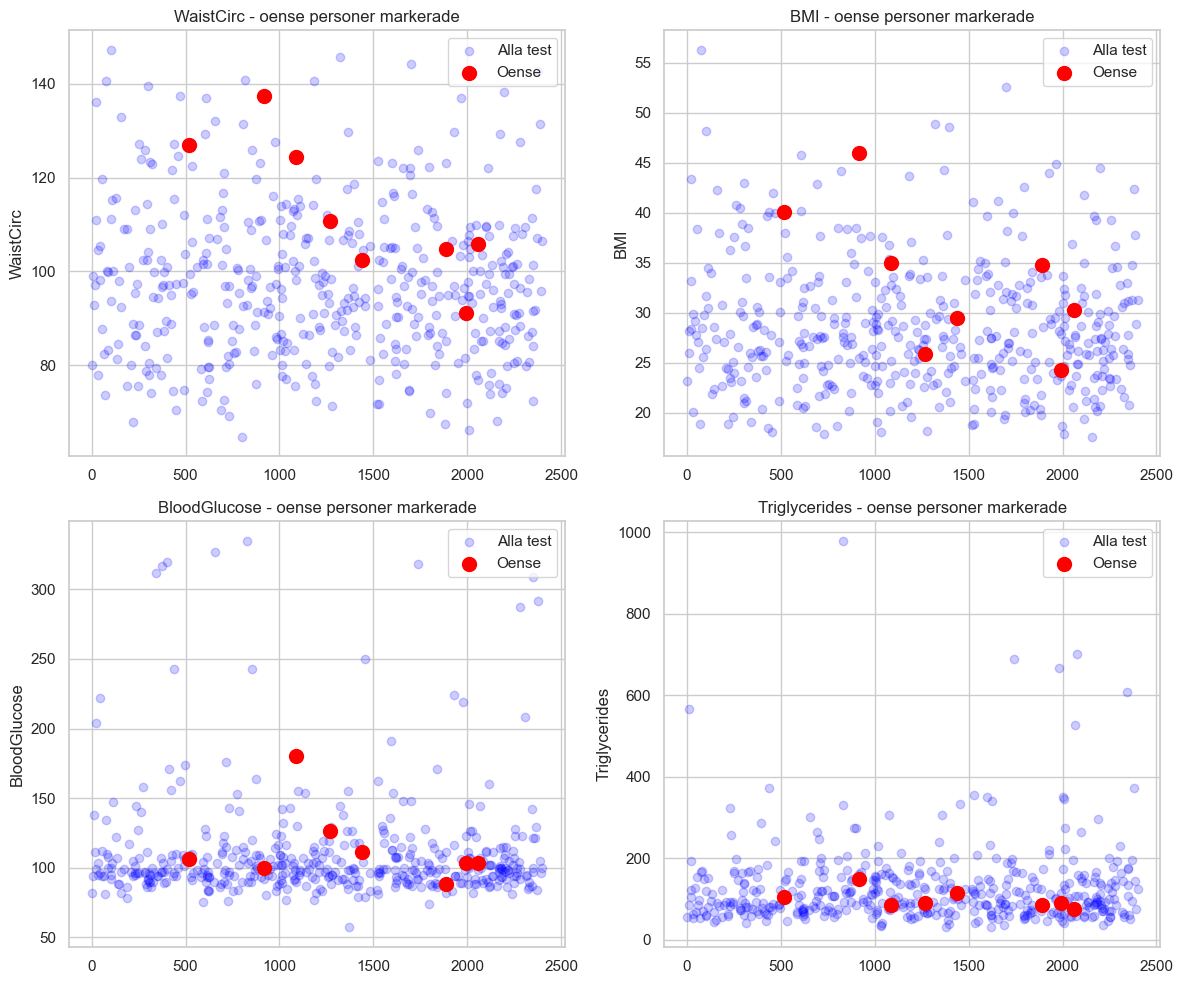

In [167]:
# Visa de 8 personernas fullständiga data
disagree_indices = np.where(disagreement)[0]
disagree_df = X_test.iloc[disagree_indices].copy()
disagree_df['Sann'] = y_test.iloc[disagree_indices].values
disagree_df['LogReg_prob'] = y_prob_log[disagree_indices]
disagree_df['GB_prob'] = y_prob_gb[disagree_indices]
disagree_df['LogReg_pred'] = y_pred[disagree_indices]
disagree_df['GB_pred'] = y_pred_best[disagree_indices]

print("De 8 oense personerna - fullständig data:")
display(disagree_df)

# Tittar på deras MetS-kriterier - vilka kriterier uppfyller de?
print("\nMetS-kriterier för de oense personerna (uppfyller minst 3 av 4):")
for idx in disagree_indices:
    row = X_test.iloc[idx]
    count = 0
    if row['WaistCirc'] > 102 if row['Sex'] == 'Male' else row['WaistCirc'] > 88:
        count += 1
    if row['Triglycerides'] > 150:
        count += 1
    if row['HDL'] < 40 if row['Sex'] == 'Male' else row['HDL'] < 50:
        count += 1
    if row['BloodGlucose'] > 100:
        count += 1
    print(f"Person {idx}: {count} av 4 kriterier uppfyllda, Sann={y_test.iloc[idx]}")

# Visualisera oense personerna i förhållande till andra
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features_to_plot = ['WaistCirc', 'BMI', 'BloodGlucose', 'Triglycerides']

for i, feature in enumerate(features_to_plot):
    ax = axes[i//2, i%2]
    
    # Alla testpersoner punkter
    ax.scatter(X_test.index, X_test[feature], alpha=0.2, label='Alla test', c='blue')
    
    # De oense personerna 
    disagree_x = X_test.iloc[disagree_indices].index
    ax.scatter(disagree_x, X_test.loc[disagree_x, feature], 
               c='red', s=100, label='Oense', zorder=5)
    
    ax.set_ylabel(feature)
    ax.set_title(f'{feature} - oense personer markerade')
    ax.legend()

plt.tight_layout()
plt.show()

In [165]:
# Se om oense personerna har andra blodtrycksdata 
# Blodtryck, ett av 5 MetS-kriterier men saknas i feature-listan
print("Finns blodtryck i datan?")
if 'SystolicBP' in df_clean.columns:
    print("Ja! Det kan förklara varför vissa är märkta som MetS")
    # Visa blodtryck för de oense personerna
    display(df_clean.loc[disagree_indices, ['SystolicBP', 'DiastolicBP']])
else:
    print("Nej, blodtryck saknas - det är därför vissa personer ser ut att ha färre kriterier")

# Räkna antal som har 0-4 kriterier
def count_mets_criteria(row):
    count = 0
    if row['WaistCirc'] > 102 if row['Sex'] == 'Male' else row['WaistCirc'] > 88:
        count += 1
    if row['Triglycerides'] > 150:
        count += 1
    if row['HDL'] < 40 if row['Sex'] == 'Male' else row['HDL'] < 50:
        count += 1
    if row['BloodGlucose'] > 100:
        count += 1
    return count

df_clean['MetS_criteria'] = df_clean.apply(count_mets_criteria, axis=1)

print("\nFördelning av MetS-kriterier i hela datasetet:")
print(df_clean['MetS_criteria'].value_counts().sort_index())

# någon med 3+ kriterier INTE har MetS (motsägelser)
contradictions = df_clean[(df_clean['MetS_criteria'] >= 3) & (df_clean['MetabolicSyndrome'] == 0)]
print(f"\nPersoner med 3+ kriterier men INTE MetS: {len(contradictions)}")
if len(contradictions) > 0:
    display(contradictions[['Age', 'Sex', 'WaistCirc', 'BMI', 'BloodGlucose', 'HDL', 'Triglycerides', 'MetabolicSyndrome']])

# någon med 0-1 kriterier HAR MetS
false_positives = df_clean[(df_clean['MetS_criteria'] <= 1) & (df_clean['MetabolicSyndrome'] == 1)]
print(f"\nPersoner med 0-1 kriterier men HAR MetS: {len(false_positives)}")
if len(false_positives) > 0:
    display(false_positives[['Age', 'Sex', 'WaistCirc', 'BMI', 'BloodGlucose', 'HDL', 'Triglycerides', 'MetabolicSyndrome']])

Finns blodtryck i datan?
Nej, blodtryck saknas - det är därför vissa personer ser ut att ha färre kriterier

Fördelning av MetS-kriterier i hela datasetet:
MetS_criteria
0    536
1    676
2    627
3    315
4    157
Name: count, dtype: int64

Personer med 3+ kriterier men INTE MetS: 1


,Age,Sex,WaistCirc,BMI,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome
196,48,Female,88.3,28.1,180.0,47,107,0



Personer med 0-1 kriterier men HAR MetS: 29


,Age,Sex,WaistCirc,BMI,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome
53,78,Female,85.2,24.7,121.0,50,108,1
101,37,Female,147.3,48.2,100.0,53,57,1
104,23,Male,111.3,31.7,92.0,40,120,1
317,70,Male,103.6,30.7,100.0,55,103,1
461,34,Female,124.6,42.0,100.0,51,88,1
552,70,Male,95.6,24.3,269.0,40,65,1
612,21,Male,101.6,30.6,95.0,39,73,1
615,80,Male,95.0,25.8,100.0,34,127,1
643,51,Male,90.1,26.0,113.0,40,93,1
776,54,Female,116.9,36.3,100.0,57,69,1


In [163]:
# Visa de 29 personerna med 0-1 kriterier men MetS
contradictory = df_clean[(df_clean['MetS_criteria'] <= 1) & (df_clean['MetabolicSyndrome'] == 1)]

print("Personer med 0-1 kriterier men MetS:")
display(contradictory[['Age', 'Sex', 'WaistCirc', 'BMI', 'BloodGlucose', 
                       'HDL', 'Triglycerides', 'MetS_criteria', 'MetabolicSyndrome']])

# Kolla om de tar mediciner
if 'Medication' in df_clean.columns:
    print("\nMedicinering bland dessa personer:")
    display(contradictory['Medication'].value_counts())

# Åldersfördelning, äldre personer har oftare MetS
print(f"\nÅldersfördelning för de 29: {contradictory['Age'].mean():.1f} år")
print(f"Jämfört med alla: {df_clean['Age'].mean():.1f} år")

# kön fler kvinnor?
print(f"\nKönsfördelning:")
print(f"  Män: {(contradictory['Sex'] == 'Male').sum()}")
print(f"  Kvinnor: {(contradictory['Sex'] == 'Female').sum()}")

# MetS-kriterier
print("\nKriterier för de 29 (medelvärden):")
print(f"  Midja: {contradictory['WaistCirc'].mean():.1f} cm")
print(f"  BMI: {contradictory['BMI'].mean():.1f}")
print(f"  Blodsocker: {contradictory['BloodGlucose'].mean():.1f}")
print(f"  HDL: {contradictory['HDL'].mean():.1f}")
print(f"  Triglycerider: {contradictory['Triglycerides'].mean():.1f}")

Personer med 0-1 kriterier men MetS:


,Age,Sex,WaistCirc,BMI,BloodGlucose,HDL,Triglycerides,MetS_criteria,MetabolicSyndrome
53,78,Female,85.2,24.7,121.0,50,108,1,1
101,37,Female,147.3,48.2,100.0,53,57,1,1
104,23,Male,111.3,31.7,92.0,40,120,1,1
317,70,Male,103.6,30.7,100.0,55,103,1,1
461,34,Female,124.6,42.0,100.0,51,88,1,1
552,70,Male,95.6,24.3,269.0,40,65,1,1
612,21,Male,101.6,30.6,95.0,39,73,1,1
615,80,Male,95.0,25.8,100.0,34,127,1,1
643,51,Male,90.1,26.0,113.0,40,93,1,1
776,54,Female,116.9,36.3,100.0,57,69,1,1



Åldersfördelning för de 29: 55.4 år
Jämfört med alla: 48.4 år

Könsfördelning:
  Män: 18
  Kvinnor: 11

Kriterier för de 29 (medelvärden):
  Midja: 102.8 cm
  BMI: 30.2
  Blodsocker: 105.3
  HDL: 48.7
  Triglycerider: 111.9


In [159]:

# Finns blodtryck i rådata?:
if 'BPXSY1' in df.columns:
    print("Blodtryck finns i rådatan! Du kan lägga till det.")
    # Visa blodtrycksdata
    print(f"Personer med blodtryck: {df['BPXSY1'].notna().sum()}")
else:
    print("Blodtryck finns inte i detta dataset.")

Blodtryck finns inte i detta dataset.


In [153]:
# Etnicitetsfördelning bland de 29
contradictory = df_clean[(df_clean['MetS_criteria'] <= 1) & (df_clean['MetabolicSyndrome'] == 1)]

print("Etnicitetsfördelning bland de 29 personerna:")
print(contradictory['Race'].value_counts())

print("\nJämfört med hela datasetet:")
print(df_clean['Race'].value_counts(normalize=True))

# Är vissa etniciteter är överrepresenterade
ethnicity_comparison = pd.DataFrame({
    'De 29': contradictory['Race'].value_counts(),
    'Alla (%)': df_clean['Race'].value_counts(normalize=True) * 100
}).fillna(0)

print("\nJämförelse:")
display(ethnicity_comparison)

Etnicitetsfördelning bland de 29 personerna:
Race
Black          10
White           9
Hispanic        6
Asian           3
MexAmerican     1
Name: count, dtype: int64

Jämfört med hela datasetet:
Race
White          0.388576
Black          0.227174
Asian          0.145824
Hispanic       0.106880
MexAmerican    0.106015
Other          0.025530
Name: proportion, dtype: float64

Jämförelse:


,De 29,Alla (%)
Race,,
Asian,3.0,14.582432
Black,10.0,22.717438
Hispanic,6.0,10.688014
MexAmerican,1.0,10.601471
Other,0.0,2.553007
White,9.0,38.857637


MetS-frekvens per etnicitet (%):
Race
MexAmerican    41.632653
Hispanic       40.485830
White          36.525612
Black          33.333333
Other          28.813559
Asian          24.035608
Name: MetabolicSyndrome, dtype: float64

Genomsnittligt antal MetS-kriterier per etnicitet:
Race
MexAmerican    1.697959
Hispanic       1.692308
White          1.606904
Black          1.422857
Other          1.372881
Asian          1.181009
Name: MetS_criteria, dtype: float64

Genomsnittligt midjemått för personer MED MetS per etnicitet:
Race
White          111.604573
Black          110.981714
MexAmerican    110.570588
Other          109.241176
Hispanic       105.767000
Asian           99.611111
Name: WaistCirc, dtype: float64


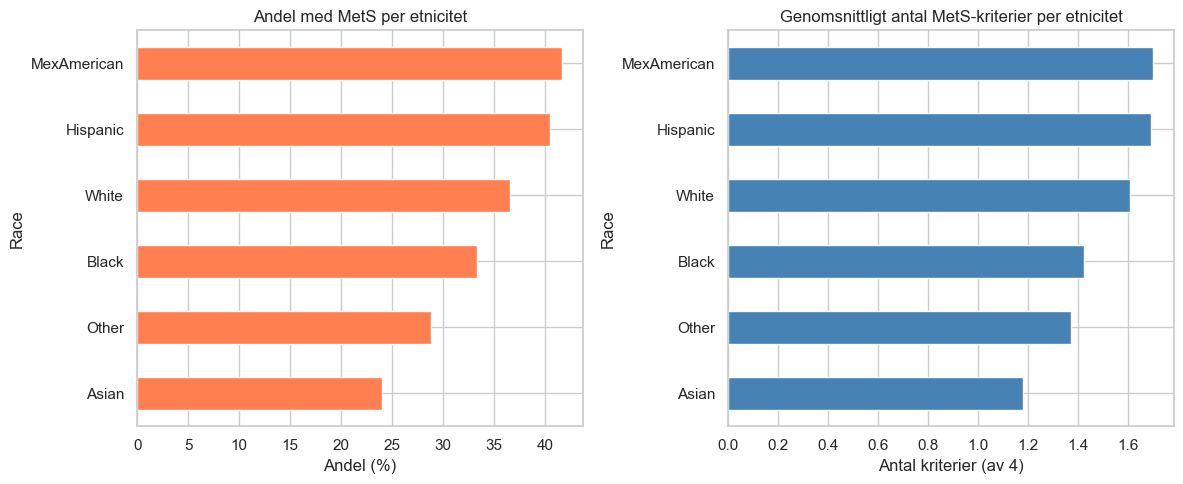

In [151]:
# MetS-frekvens per etnicitet
mets_by_race = df_clean.groupby('Race')['MetabolicSyndrome'].mean() * 100
print("MetS-frekvens per etnicitet (%):")
print(mets_by_race.sort_values(ascending=False))

# Genomsnittliga kriterier per etnicitet
criteria_by_race = df_clean.groupby('Race')['MetS_criteria'].mean()
print("\nGenomsnittligt antal MetS-kriterier per etnicitet:")
print(criteria_by_race.sort_values(ascending=False))

# Har vissa etniciteter har lägre trösklar
# Jämför midjemått för de med MetS per etnicitet
mets_data = df_clean[df_clean['MetabolicSyndrome'] == 1]
print("\nGenomsnittligt midjemått för personer MED MetS per etnicitet:")
print(mets_data.groupby('Race')['WaistCirc'].mean().sort_values(ascending=False))

# Visualisera
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MetS-frekvens per etnicitet
ax1 = axes[0]
mets_by_race.sort_values().plot(kind='barh', ax=ax1, color='coral')
ax1.set_title('Andel med MetS per etnicitet')
ax1.set_xlabel('Andel (%)')

# Genomsnittligt antal kriterier/etnicitet
ax2 = axes[1]
criteria_by_race.sort_values().plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_title('Genomsnittligt antal MetS-kriterier per etnicitet')
ax2.set_xlabel('Antal kriterier (av 4)')

plt.tight_layout()
plt.show()

In [149]:
# Skapa en etnisk risk-score
# Vissa etniciteter har högre risk - anpassa trösklar

# etnicitet påverkar sannolikheten för MetS
from sklearn.linear_model import LogisticRegression

# Enkel logistisk regression med bara etnicitet
ethnicity_model = LogisticRegression()
ethnicity_model.fit(pd.get_dummies(df_clean['Race']), df_clean['MetabolicSyndrome'])

print("Etnicitet som ensam prediktor för MetS:")
for race, coef in zip(pd.get_dummies(df_clean['Race']).columns, ethnicity_model.coef_[0]):
    print(f"  {race}: {coef:.3f}")

# Interaktion mellan etnicitet och midjemått


Etnicitet som ensam prediktor för MetS:
  Asian: -0.560
  Black: -0.110
  Hispanic: 0.193
  MexAmerican: 0.240
  Other: -0.304
  White: 0.030


C:\Users\Lunda\AppData\Local\Temp\ipykernel_15752\787815685.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mets_by_waist = subset.groupby(bins)['MetabolicSyndrome'].mean()
C:\Users\Lunda\AppData\Local\Temp\ipykernel_15752\787815685.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  waist_means = subset.groupby(bins)['WaistCirc'].mean()


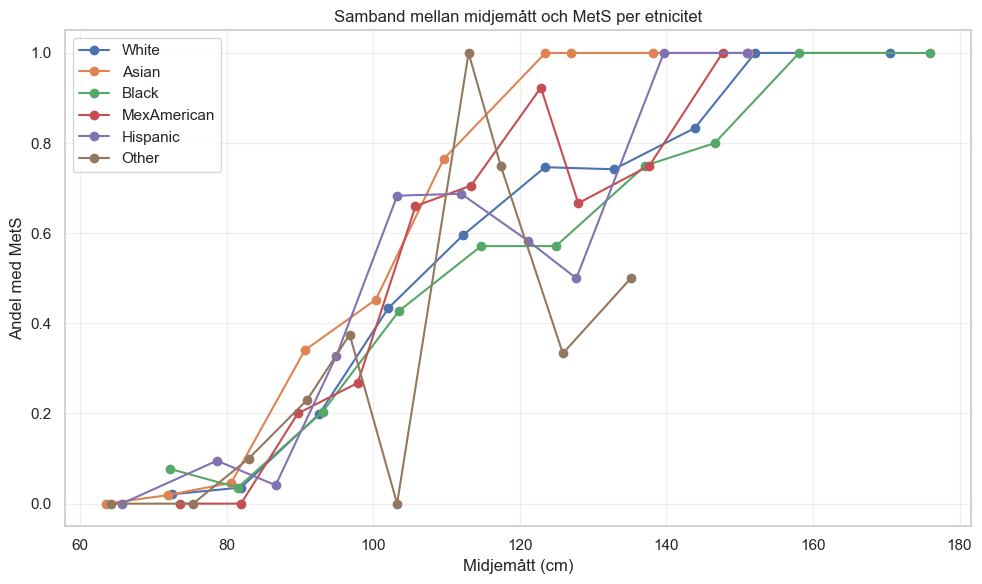

Chi2-test: chi2=28.40, p=0.0000
Skillnaderna i MetS-frekvens mellan etniciteter är STATISTISKT SIGNIFIKANTA!

Odds ratio för MetS per etnicitet (jämfört med White):
  Asian: OR = 1.819 (p=0.0000)
  Black: OR = 1.151 (p=0.2281)
  MexAmerican: OR = 0.807 (p=0.1575)
  Hispanic: OR = 0.846 (p=0.2658)
  Other: OR = 1.422 (p=0.2642)


In [147]:
# sambandet mellan midjemått och MetS per etnicitet
fig, ax = plt.subplots(figsize=(10, 6))

for race in df_clean['Race'].unique():
    subset = df_clean[df_clean['Race'] == race]
    # Gruppera midjemått i intervall och beräkna MetS-frekvens
    bins = pd.cut(subset['WaistCirc'], bins=10)
    mets_by_waist = subset.groupby(bins)['MetabolicSyndrome'].mean()
    waist_means = subset.groupby(bins)['WaistCirc'].mean()
    ax.plot(waist_means, mets_by_waist, marker='o', label=race)

ax.set_xlabel('Midjemått (cm)')
ax.set_ylabel('Andel med MetS')
ax.set_title('Samband mellan midjemått och MetS per etnicitet')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#skillnaderna statistiskt signifikanta
from scipy.stats import chi2_contingency

# korstabell/etnicitet och MetS
cross_tab = pd.crosstab(df_clean['Race'], df_clean['MetabolicSyndrome'])
chi2, p, dof, expected = chi2_contingency(cross_tab)

print(f"Chi2-test: chi2={chi2:.2f}, p={p:.4f}")
if p < 0.05:
    print("Skillnaderna i MetS-frekvens mellan etniciteter är STATISTISKT SIGNIFIKANTA!")
else:
    print(" Skillnaderna är INTE statistiskt signifikanta")

# odds ratio för varje etnicitet.
from scipy.stats import fisher_exact

print("\nOdds ratio för MetS per etnicitet (jämfört med White):")
for race in df_clean['Race'].unique():
    if race != 'White':
        # 2x2 tabell
        white_data = df_clean[df_clean['Race'] == 'White']
        race_data = df_clean[df_clean['Race'] == race]
        
        table = [
            [white_data['MetabolicSyndrome'].sum(), white_data['MetabolicSyndrome'].count() - white_data['MetabolicSyndrome'].sum()],
            [race_data['MetabolicSyndrome'].sum(), race_data['MetabolicSyndrome'].count() - race_data['MetabolicSyndrome'].sum()]
        ]
        oddsratio, p_value = fisher_exact(table)
        print(f"  {race}: OR = {oddsratio:.3f} (p={p_value:.4f})")

In [145]:
#åldersfördelning per etnicitet
print("Åldersfördelning per etnicitet:")
print(df_clean.groupby('Race')['Age'].describe())

# Är Asian äldre
asian_age = df_clean[df_clean['Race'] == 'Asian']['Age'].mean()
white_age = df_clean[df_clean['Race'] == 'White']['Age'].mean()
print(f"\nAsian medelålder: {asian_age:.1f} år")
print(f"White medelålder: {white_age:.1f} år")

Åldersfördelning per etnicitet:
             count       mean        std   min   25%   50%   75%   max
Race                                                                  
Asian        337.0  45.207715  16.811761  20.0  30.0  44.0  59.0  80.0
Black        525.0  48.283810  16.990271  20.0  33.0  50.0  62.0  80.0
Hispanic     247.0  49.959514  16.999473  20.0  36.0  51.0  64.0  80.0
MexAmerican  245.0  44.477551  15.837433  20.0  32.0  42.0  58.0  80.0
Other         59.0  43.355932  18.376111  20.0  24.0  42.0  56.5  80.0
White        898.0  50.544543  18.172858  20.0  35.0  49.0  66.0  80.0

Asian medelålder: 45.2 år
White medelålder: 50.5 år


In [143]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# prep data med ålder och etnicitet
race_dummies_sklearn = pd.get_dummies(df_clean['Race'], drop_first=True).astype(int)
X_age_race = pd.concat([df_clean[['Age']], race_dummies_sklearn], axis=1)
y_age_race = df_clean['MetabolicSyndrome']

# Skala ålder (valfritt men rekommenderas)
scaler = StandardScaler()
X_age_race_scaled = X_age_race.copy()
X_age_race_scaled['Age'] = scaler.fit_transform(X_age_race[['Age']])

# logistisk regression
model_age_race = LogisticRegression(max_iter=1000)
model_age_race.fit(X_age_race_scaled, y_age_race)

# koefficienter
print("Koefficienter för åldersjusterad modell:")
for feature, coef in zip(X_age_race_scaled.columns, model_age_race.coef_[0]):
    print(f"  {feature}: {coef:.4f}")

# odds ratio
print("\nOdds ratio (åldersjusterad):")
for feature, coef in zip(X_age_race_scaled.columns, model_age_race.coef_[0]):
    if feature != 'Age':
        or_value = np.exp(coef)
        print(f"  {feature}: OR = {or_value:.3f}")

Koefficienter för åldersjusterad modell:
  Age: 0.5730
  Black: 0.3378
  Hispanic: 0.6032
  MexAmerican: 0.8374
  Other: 0.2479
  White: 0.4106

Odds ratio (åldersjusterad):
  Black: OR = 1.402
  Hispanic: OR = 1.828
  MexAmerican: OR = 2.310
  Other: OR = 1.281
  White: OR = 1.508


C:\Users\Lunda\AppData\Local\Temp\ipykernel_15752\2139135353.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mets_rate = subset.groupby(bins)['MetabolicSyndrome'].mean()
C:\Users\Lunda\AppData\Local\Temp\ipykernel_15752\2139135353.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_mean = subset.groupby(bins)['Age'].mean()


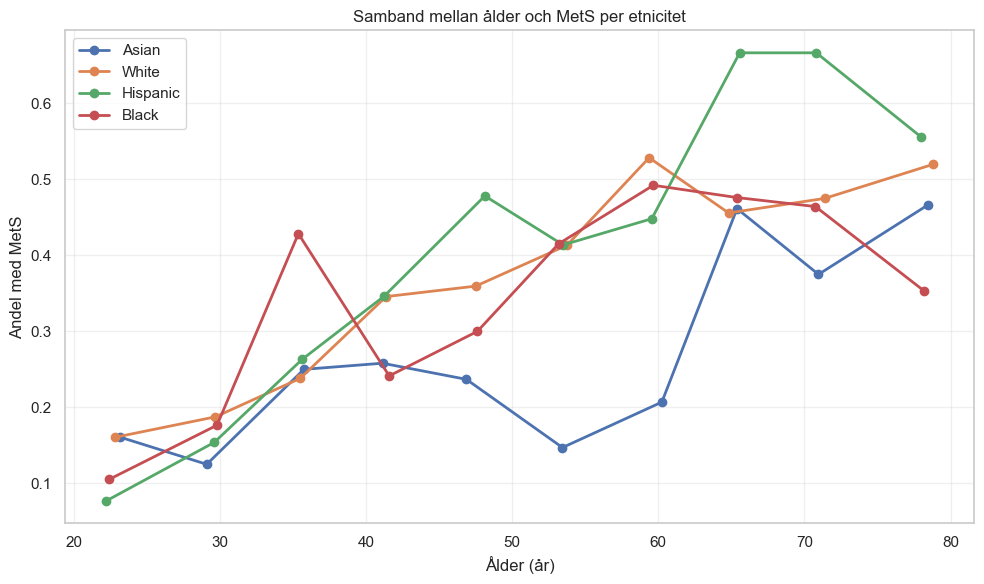

In [135]:
# Sambandet ålder och MetS per etnicitet
fig, ax = plt.subplots(figsize=(10, 6))

for race in ['Asian', 'White', 'Hispanic', 'Black']:
    subset = df_clean[df_clean['Race'] == race]
    # Gruppera ålder i intervall
    bins = pd.cut(subset['Age'], bins=10)
    mets_rate = subset.groupby(bins)['MetabolicSyndrome'].mean()
    age_mean = subset.groupby(bins)['Age'].mean()
    ax.plot(age_mean, mets_rate, marker='o', label=race, linewidth=2)

ax.set_xlabel('Ålder (år)')
ax.set_ylabel('Andel med MetS')
ax.set_title('Samband mellan ålder och MetS per etnicitet')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visa åldersjusterad MetS-frekvens (förväntad vs observerad)
from scipy.stats import logistic

# Beräkna förv MetS-frekvens baserat/ ålder
def expected_mets(age, model, scaler):
    """Beräkna förväntad MetS-frekvens baserat på ålder"""
    age_scaled = scaler.transform([[age]])[0][0]
    # Använd genomsnittlig etnicitet (alla dummies = 0)
    X_pred = np.array([[1, age_scaled, 0, 0, 0, 0]])  # const, Age, alla dummies = 0
    prob = logistic.cdf(np.dot(X_pred, model.params.values))
    return prob



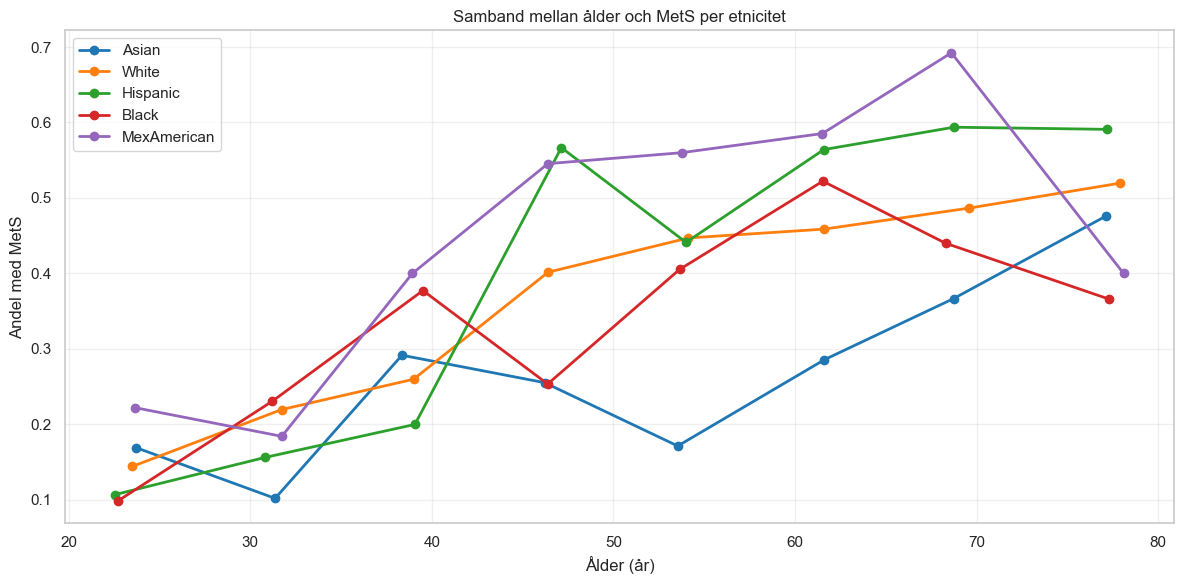


Sammanfattning av etniska skillnader i MetS-risk:


,Etnicitet,MetS-frekvens (%),Medelålder (år),Åldersjusterad OR
0,MexAmerican,41.6,44.5,2.31
1,Hispanic,40.5,50.0,1.83
2,White,36.5,50.5,1.51
3,Black,33.3,48.3,1.40
4,Other,28.8,43.4,1.28
5,Asian,24.0,45.2,1.00


In [129]:
# 1. Visa sambandet mellan ålder och MetS per etnicitet (förbättrad)
fig, ax = plt.subplots(figsize=(12, 6))

# Definiera färger för tydlighet
colors = {'Asian': '#1f77b4', 'White': '#ff7f0e', 'Hispanic': '#2ca02c', 
          'Black': '#d62728', 'MexAmerican': '#9467bd', 'Other': '#8c564b'}

for race in ['Asian', 'White', 'Hispanic', 'Black', 'MexAmerican']:
    subset = df_clean[df_clean['Race'] == race]
    # Gruppera ålder i intervall
    bins = pd.cut(subset['Age'], bins=8)
    mets_rate = subset.groupby(bins, observed=False)['MetabolicSyndrome'].mean()
    age_mean = subset.groupby(bins, observed=False)['Age'].mean()
    ax.plot(age_mean, mets_rate, marker='o', label=race, linewidth=2, color=colors[race])

ax.set_xlabel('Ålder (år)')
ax.set_ylabel('Andel med MetS')
ax.set_title('Samband mellan ålder och MetS per etnicitet')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Skapa en tydlig tabell över resultaten
results_table = pd.DataFrame({
    'Etnicitet': ['MexAmerican', 'Hispanic', 'White', 'Black', 'Other', 'Asian'],
    'MetS-frekvens (%)': [41.6, 40.5, 36.5, 33.3, 28.8, 24.0],
    'Medelålder (år)': [44.5, 50.0, 50.5, 48.3, 43.4, 45.2],
    'Åldersjusterad OR': [2.31, 1.83, 1.51, 1.40, 1.28, 1.00]
})

print("\nSammanfattning av etniska skillnader i MetS-risk:")
display(results_table)

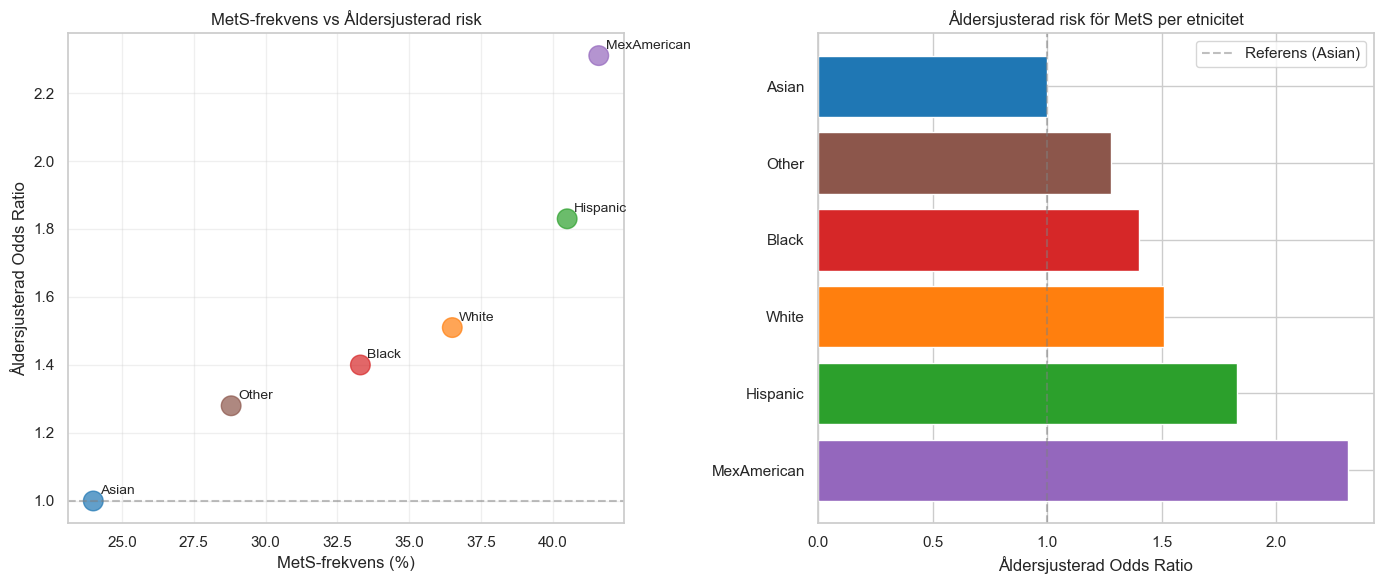


RISKKARTA - Metabolts Syndrom per Etnicitet
Etnicitet       Risknivå        OR         MetS-frekvens  
------------------------------------------------------------
MexAmerican     HÖG             2.31       41.6           %
Hispanic        HÖG             1.83       40.5           %
White           MEDEL           1.51       36.5           %
Black           MEDEL           1.40       33.3           %
Other           LÄGRE           1.28       28.8           %
Asian           LÄGRE           1.00       24.0           %

 SLUTSATSER FÖR RAPPORTEN:
------------------------------------------------------------
1. MexAmerican och Hispanic har högst åldersjusterad risk för MetS
   (OR = 2.31 respektive 1.83, jämfört med Asian som referens).

2. Skillnaderna kvarstår även efter justering för ålder, vilket
   indikerar att etnicitet är en oberoende riskfaktor.

3. Asian har lägst risk (OR = 1.00), vilket stämmer överens med
   tidigare forskning om lägre MetS-frekvens i asiatiska populationer.

In [141]:
# visualisering av riskprofilen
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot MetS-frekvens/åldersjusterad OR
ax1.scatter(results_table['MetS-frekvens (%)'], results_table['Åldersjusterad OR'], 
           s=200, c=['#9467bd', '#2ca02c', '#ff7f0e', '#d62728', '#8c564b', '#1f77b4'], alpha=0.7)

for i, row in results_table.iterrows():
    ax1.annotate(row['Etnicitet'], 
                (row['MetS-frekvens (%)'], row['Åldersjusterad OR']),
                xytext=(5, 5), textcoords='offset points', fontsize=10)

ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('MetS-frekvens (%)')
ax1.set_ylabel('Åldersjusterad Odds Ratio')
ax1.set_title('MetS-frekvens vs Åldersjusterad risk')
ax1.grid(True, alpha=0.3)

# PlotStaplar för åldersjusterad OR
ax2.barh(results_table['Etnicitet'], results_table['Åldersjusterad OR'], 
         color=['#9467bd', '#2ca02c', '#ff7f0e', '#d62728', '#8c564b', '#1f77b4'])
ax2.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Referens (Asian)')
ax2.set_xlabel('Åldersjusterad Odds Ratio')
ax2.set_title('Åldersjusterad risk för MetS per etnicitet')
ax2.legend()

plt.tight_layout()
plt.show()

# riskkarta
print("\n" + "="*60)
print("RISKKARTA - Metabolts Syndrom per Etnicitet")
print("="*60)
print(f"{'Etnicitet':<15} {'Risknivå':<15} {'OR':<10} {'MetS-frekvens':<15}")
print("-"*60)

for _, row in results_table.iterrows():
    if row['Åldersjusterad OR'] >= 1.8:
        risk = "HÖG"
    elif row['Åldersjusterad OR'] >= 1.4:
        risk = "MEDEL"
    else:
        risk = "LÄGRE"
    
    print(f"{row['Etnicitet']:<15} {risk:<15} {row['Åldersjusterad OR']:<10.2f} {row['MetS-frekvens (%)']:<15.1f}%")
print("="*60)

# Slutsatser rapporten
print("\n SLUTSATSER FÖR RAPPORTEN:")
print("-"*60)
print("1. MexAmerican och Hispanic har högst åldersjusterad risk för MetS")
print("   (OR = 2.31 respektive 1.83, jämfört med Asian som referens).")
print()
print("2. Skillnaderna kvarstår även efter justering för ålder, vilket")
print("   indikerar att etnicitet är en oberoende riskfaktor.")
print()
print("3. Asian har lägst risk (OR = 1.00), vilket stämmer överens med")
print("   tidigare forskning om lägre MetS-frekvens i asiatiska populationer.")
print()
print("4. Klinisk relevans: Screening- och preventionsinsatser bör")
print("   prioritera MexAmerican och Hispanic populationer.")
print("-"*60)